In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [3]:
import tensorflow as tf 
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
X,y=make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

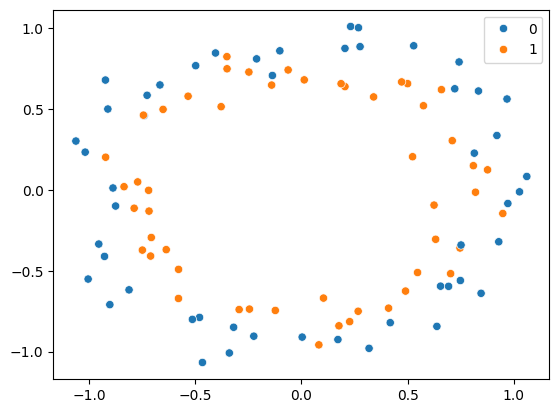

In [15]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [17]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,verbose=1)

Epoch 1/3500
3/3 [==============================] - 0s 50ms/step - loss: 0.6944 - accuracy: 0.4875 - val_loss: 0.7014 - val_accuracy: 0.4000
Epoch 2/3500
3/3 [==============================] - 0s 15ms/step - loss: 0.6910 - accuracy: 0.5375 - val_loss: 0.7066 - val_accuracy: 0.3000
Epoch 3/3500
3/3 [==============================] - 0s 15ms/step - loss: 0.6889 - accuracy: 0.5625 - val_loss: 0.7122 - val_accuracy: 0.3000
Epoch 4/3500
3/3 [==============================] - 0s 16ms/step - loss: 0.6866 - accuracy: 0.5500 - val_loss: 0.7172 - val_accuracy: 0.3500
Epoch 5/3500
3/3 [==============================] - 0s 16ms/step - loss: 0.6849 - accuracy: 0.5625 - val_loss: 0.7229 - val_accuracy: 0.3500
Epoch 6/3500
3/3 [==============================] - 0s 17ms/step - loss: 0.6834 - accuracy: 0.5625 - val_loss: 0.7278 - val_accuracy: 0.3500
Epoch 7/3500
3/3 [==============================] - 0s 16ms/step - loss: 0.6829 - accuracy: 0.5625 - val_loss: 0.7333 - val_accuracy: 0.3500
Epoch 8/3500


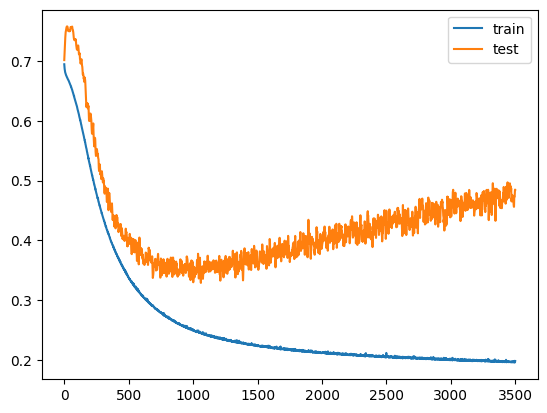

In [21]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 7s 694us/step


<Axes: >

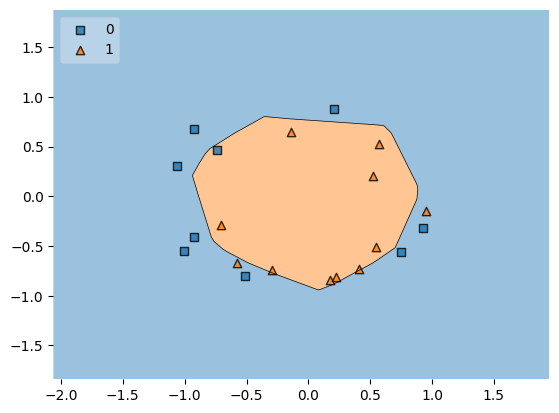

In [22]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)

Early Stopping

In [24]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [25]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [29]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=30,
    verbose=1,
    mode='min',
    baseline=None,
    restore_best_weights=False
)

In [30]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500
3/3 [==============================] - 0s 26ms/step - loss: 0.6623 - accuracy: 0.5875 - val_loss: 0.7626 - val_accuracy: 0.3500
Epoch 2/3500
3/3 [==============================] - 0s 14ms/step - loss: 0.6615 - accuracy: 0.6000 - val_loss: 0.7635 - val_accuracy: 0.3500
Epoch 3/3500
3/3 [==============================] - 0s 14ms/step - loss: 0.6610 - accuracy: 0.6000 - val_loss: 0.7624 - val_accuracy: 0.3500
Epoch 4/3500
3/3 [==============================] - 0s 15ms/step - loss: 0.6604 - accuracy: 0.6000 - val_loss: 0.7623 - val_accuracy: 0.3500
Epoch 5/3500
3/3 [==============================] - 0s 15ms/step - loss: 0.6597 - accuracy: 0.6000 - val_loss: 0.7618 - val_accuracy: 0.3500
Epoch 6/3500
3/3 [==============================] - 0s 15ms/step - loss: 0.6591 - accuracy: 0.6000 - val_loss: 0.7614 - val_accuracy: 0.3500
Epoch 7/3500
3/3 [==============================] - 0s 14ms/step - loss: 0.6587 - accuracy: 0.5875 - val_loss: 0.7623 - val_accuracy: 0.3000
Epoch 8/3500


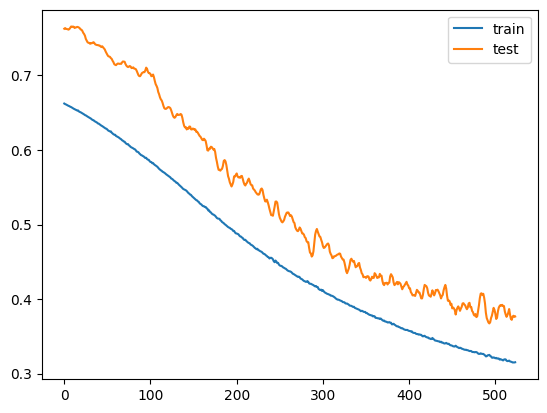

In [31]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 [==============================] - 7s 725us/step


<Axes: >

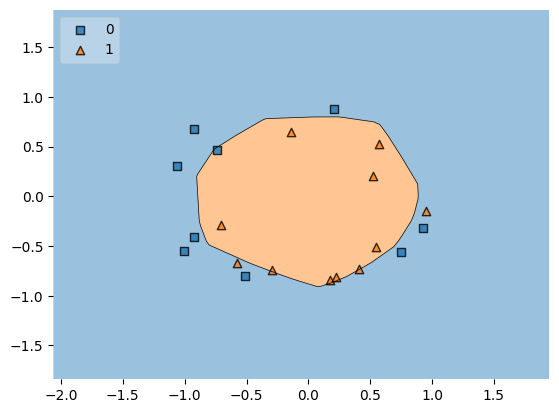

In [32]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
